## Anaylse day 3 clinical results, with sensitivitiy analyses

In this notebook, I focus mainly on addressing the reviewer comments and including a sensitivity analysis

In [1]:
import os
import re
import datetime
import pandas as pd
import numpy as np

pd.options.mode.chained_assignment = None 
import seaborn as sns
import scipy.stats as ss

from dataclasses import dataclass

import statsmodels.formula.api as smf
import statsmodels.api as sm
from firthmodels.adapters.statsmodels import FirthLogit # for regularised regression
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep # for proportion confidence intervals

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [2]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [3]:
DIR_FIGS = "../figures/fig4"
DIR_OUTPUT = "../figures/response/sensitivity"
DIR_TABLES = "../tables"
os.makedirs(DIR_OUTPUT, exist_ok=True)
save_results = True

In [4]:
W = 3.4 # roughly width of one column

## Functions and Globals

In [5]:
INDEX_NAMES = {
    "n_patients": "N",
    "age": "Median Age (IQR) - yr",
    "fever": "Fever - n (%)",
    "sex_female": "Female sex - n (%)",
    "day0_parasite_density_thousands": "Median parasity density (IQR) - mm$^3$",
    "prevalence": "Prevalence of A724E (95% CI) - %",
    "mutant_A724E": "724E (Mutant)",
    "wildtype_A724E": "724A (Wildtype)"
}
COLUMN_NAMES = {
    "complete": "Retained", 
    "lost": "Lost", 
    True: "Positive on Day 3",
    False: "Negative on Day 3",
    "test": "Test", 
    "pvalue": "P"
}
COVARIATE_NAMES = {"C(sex)[T.M]": "Sex",
                   "C(fever)[T.Yes]": "Fever",
                   "age": "Age",
                   "day0_parasite_density_log10": "Parasity density [log10]",
                   "const": "Intercept",
                   "sex_M": "Sex",
                   "fever_Yes": "Fever",
                   "724_mutant": "724E (Mutant)"
}

##### Descriptive

In [6]:
P = lambda n, N: f"{n} ({100*n/N:.2f}%) of {N}"

In [7]:
def get_median_and_iqrs(x: np.ndarray) -> str:
    med = np.nanmedian(x)
    iqrs = np.nanquantile(x, [0.25, 0.75])
    return f"{med:.1f} ({iqrs[0]:.1f} - {iqrs[1]:.1f})"

In [8]:
def get_number_and_percent(x: np.ndarray, val: str) -> str:
    N = x.shape[0]
    n = (x == val).sum()
    return f"{n} ({100*n/N:.1f})"

In [9]:
def get_mutation_prevalence_and_cis(x) -> str:
    # Remove missing
    x = x.dropna()
    
    # Genotypes
    n_passed = (x != './.').sum()
    n_wt = (x == '0/0').sum()
    n_mixed = (x == '0/1').sum()
    n_mut = (x == '1/1').sum()

    return get_exact_cis(n=n_mut + n_mixed, N=n_passed)

    # Prevalence and CIs
    # prev = 100 * (n_mut + n_mixed) / n_passed
    # low, high = proportion_confint(
    #     n_mut + n_mixed,
    #     n_passed,
    #     alpha=0.05,
    #     method="beta",
    # )

    # return f"{prev:.1f} ({100*low:.1f}-{100*high:.1f})"

In [10]:
def get_exact_cis(n, N, method: str = 'beta') -> str:
    prev = n / N * 100
    low, high = proportion_confint(n, N, alpha=0.05, method=method)
    return f"{prev:.1f} ({100*low:.1f}-{100*high:.1f})"

##### Hypothesis testing

In [11]:
class HypothesisTester:
    def __init__(self, groups: str, data: pd.DataFrame) -> None:
        self.groups = groups
        self.data = data
    
    def mannu(self, factor: str) -> float:
        """ Mann-Whitney U Test"""
        values = [list(df[factor]) for _, df in self.data.groupby(self.groups)]
        return ss.mannwhitneyu(*values, nan_policy='omit')

    def chisq(self, factor: str) -> float:
        """ Chi-squared Test"""
        return ss.chi2_contingency(pd.crosstab(self.data[self.groups], self.data[factor]))

    def fisher(self, factor: str) -> float:
        return ss.fisher_exact(pd.crosstab(self.data[self.groups], self.data[factor]))

In [12]:
@dataclass
class UniResult:
    variable: str
    test: str
    pvalue: float

    def __post_init__(self):
        self.pvalue = round(self.pvalue, 3) if isinstance(self.pvalue, float) else self.pvalue

In [13]:
def convert_logistic_to_output_table(model, covariate_map: dict[str, str] = COVARIATE_NAMES) -> pd.DataFrame:
    """
    Convert the output of a logistic regression to a clean table for publication
    
    """

    # Extract odds ratios
    OR = np.exp(model.params)

    # Get confidence intervals
    if isinstance(model.conf_int(), pd.DataFrame):
        low, high = np.exp(model.conf_int()[0]), np.exp(model.conf_int()[1])
    elif isinstance(model.conf_int(), np.ndarray):
        low, high = np.exp(model.conf_int()[:, 0]), np.exp(model.conf_int()[:, 1])
        
    # Prepare table
    df = pd.DataFrame({
        "Covariate": model.model.exog_names,
        #"Coefficient (SE)": [f"{round(c, 2)} ({round(se, 2)})" for c, se in zip(model.params, model.bse)],
        "Odds Ratio (95% CI)": [f"{round(o, 1)} ({round(l, 1)}-{round(h, 1)})" for o, l, h in zip(OR, low, high)],
        "P": [round(p, 3) for p in model.pvalues]
    })
    
    df.set_index("Covariate", inplace=True)
    df.rename(covariate_map, inplace=True)
    
    return df

## Load and filter data

In [14]:
df = pd.read_csv(f"{DIR_FIGS}/ceadriz.merged.csv")

In [15]:
ct_filter = pd.crosstab(
    df["status"],
    df["day0_seqdone"],
    margins=True,
    dropna=False,
)
ct_filter

day0_seqdone,False,True,All
status,,,
complete,5,98,103
lost,8,77,85
not_enrolled,105,13,118
All,118,188,306


In [16]:
N = ct_filter['All']['complete']
n = ct_filter[True]['complete']
n_pos = df.query("status == 'complete'")["day3_pos"].sum()
n_pos_seq0 = df.query("status == 'complete' and day3_pos")["day0_seqdone"].sum()
n_pos_seq3 = df.query("status == 'complete' and day3_pos")["day3_seqdone"].sum()
print(f"""
We have {P(N, ct_filter['All']['All'] - ct_filter['All']['not_enrolled'])} participants who returned on day 3.
  {P(n_pos, N)} had parasites dectable by microscopy.
  {P(n, N)} having sequencing data for day 0.

Of the day 3 positive samples, 
  {P(n_pos_seq0, n_pos)} have sequencing complete for day 0.
  {P(n_pos_seq3, n_pos)} have sequencing complete for day 3.
""")


We have 103 (54.79%) of 188 participants who returned on day 3.
  21 (20.39%) of 103 had parasites dectable by microscopy.
  98 (95.15%) of 103 having sequencing data for day 0.

Of the day 3 positive samples, 
  21 (100.00%) of 21 have sequencing complete for day 0.
  17 (80.95%) of 21 have sequencing complete for day 3.



### Assess whether there is any bias in the lost to follow-up

In [17]:
df_enrolled = df.query("status != 'not_enrolled'")
df_enrolled["status"].value_counts(dropna=False)

status
complete    103
lost         85
Name: count, dtype: int64

In [18]:
pd.crosstab(
    df_enrolled["status"],
    df_enrolled["day0_a724_mutant"],
    margins=True,
    dropna=False
) # NaN are sequencing failures

day0_a724_mutant,mutant,wildtype,NaN,All
status,,,,
complete,75,23,5,103
lost,63,14,8,85
All,138,37,0,188


##### Univariate analysis

In [19]:
_df_bias = (df_enrolled.groupby("status")
    .agg(
        n_patients=pd.NamedAgg("sample_id", lambda x: len(x)),
        age = pd.NamedAgg("age", get_median_and_iqrs),
        day0_parasite_density_thousands = pd.NamedAgg("day0_parasite_density", lambda x: get_median_and_iqrs(x/10**3)),
        sex_female=pd.NamedAgg("sex", lambda x: get_number_and_percent(x, "F")),
        fever=pd.NamedAgg("fever", lambda x: get_number_and_percent(x, "Yes")), 
        prevalence=pd.NamedAgg("day0_a724_gt", get_mutation_prevalence_and_cis),
        # n_mixed=pd.NamedAgg("day0_a724_gt", lambda x: get_number_and_percent(x, '0/1')),
        # n_mut=pd.NamedAgg("day0_a724_gt", lambda x: get_number_and_percent(x, '1/1')),
    )
).transpose()

In [20]:
tester = HypothesisTester(data=df_enrolled, groups="status")
tester_seqdata = HypothesisTester(data=df_enrolled.query("day0_seqdone"), groups="status")
_df_stats = pd.DataFrame(
    [
        UniResult("n_patients", "-", "-"),
        UniResult("age", "Mann-Whitney $U$", tester.mannu("age").pvalue),
        UniResult("day0_parasite_density_thousands", "Mann-Whitney $U$", tester.mannu("day0_parasite_density").pvalue),
        UniResult("sex_female", "$X^2$", tester.chisq("sex").pvalue),
        UniResult("fever", "$X^2$", tester.chisq("fever").pvalue),
        UniResult("prevalence", "$X^2$", tester_seqdata.chisq("day0_a724_mutant").pvalue),
    ]
)
_df_stats.set_index('variable', inplace=True)

In [21]:
df_lost_bias = pd.concat([_df_bias, _df_stats], axis=1)
df_lost_bias = df_lost_bias.rename(INDEX_NAMES).rename(COLUMN_NAMES, axis=1)
df_lost_bias

,Retained,Lost,Test,P
N,103,85,-,-
Median Age (IQR) - yr,12.0 (6.2 - 17.0),11.5 (6.0 - 20.0),Mann-Whitney $U$,0.853
Median parasity density (IQR) - mm$^3$,26.4 (14.0 - 54.8),29.3 (9.7 - 52.9),Mann-Whitney $U$,0.564
Female sex - n (%),54 (52.4),39 (45.9),$X^2$,0.503
Fever - n (%),23 (22.3),14 (16.5),$X^2$,0.362
Prevalence of A724E (95% CI) - %,76.5 (66.9-84.5),81.8 (71.4-89.7),$X^2$,0.507


In [22]:
if save_results:
    df_lost_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz-lost-bias.csv")
    df_lost_bias.to_excel(f"{DIR_TABLES}/stable_ceadriz-lost-bias.xlsx")

##### Multivariate analysis

In [23]:
# Prepare variables for multivaraiate analysis
df_enrolled["outcome"] = df_enrolled["status"].map({"complete": 0, "lost": 1})
df_enrolled["day0_a724_gt_int"] = df_enrolled["day0_a724_gt"].map({"./.": None, "0/0": 0, "0/1": 1, "1/1": 2})

# Fit model and display
model = smf.logit(
    "outcome ~ age + day0_parasite_density_log10 + C(sex) + C(fever) + day0_a724_gt_int",
    data=df_enrolled
).fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.679438
         Iterations 4
                              Results: Logit
Model:                   Logit               Method:              MLE     
Dependent Variable:      outcome             Pseudo R-squared:    0.008   
Date:                    2026-08-24 19:52    AIC:                 233.4969
No. Observations:        163                 BIC:                 252.0594
Df Model:                5                   Log-Likelihood:      -110.75 
Df Residuals:            157                 LL-Null:             -111.63 
Converged:               1.0000              LLR p-value:         0.88177 
No. Iterations:          4.0000              Scale:               1.0000  
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
--------------------------------------------------------------------------
Intercept                   

In [24]:
df_lost_logit = convert_logistic_to_output_table(model)
df_lost_logit

,Odds Ratio (95% CI),P
Covariate,,
Intercept,3.3 (0.1-107.9),0.502
Sex,1.1 (0.6-2.0),0.878
Fever,0.7 (0.3-1.7),0.460
Age,1.0 (1.0-1.0),0.467
Parasity density [log10],0.8 (0.4-1.6),0.495
day0_a724_gt_int,0.9 (0.6-1.4),0.758


- The intercept is not meaningful, and should probably be dropped

In [25]:
if save_results:
    df_lost_logit.to_excel(f"{DIR_TABLES}/stable_ceadriz-lost-logit.xlsx")
    df_lost_logit.to_latex(f"{DIR_TABLES}/stable_ceadriz-lost-logit.tex", index=True)

- Include the summary text here
- Write the file as supplementary table

## Checking for an association between A724E and day 3 positivity

##### Statistical evaluation
- First, once more, let's breakdown what actually gets included in the following analysis
- Then we can do this clean fishers exact, and write table
- Then the full univariate
- Then the multivariate

In [26]:
N_enrolled = df_enrolled.shape[0]
N_complete = df_enrolled.query("status == 'complete'").shape[0]

N_day0seq = df_enrolled.query("status == 'complete' and day0_seqdone").shape[0]
N_day0passed = df_enrolled.query("status == 'complete' and day0_seqdone and day0_a724_mutant != 'failed'").shape[0]

N_day3pos = df_enrolled.query("status == 'complete' and day3_pos").shape[0]
N_day3posseq = df_enrolled.query("status == 'complete' and day3_pos and day0_seqdone").shape[0]
N_day3posseqpass = df_enrolled.query("status == 'complete' and day3_pos and day0_seqdone and day0_a724_mutant != 'failed'").shape[0]

In [27]:
df_filter = (df_enrolled
    .query("status == 'complete'") # returned
    .query("day0_seqdone") # sequenced 
    .query("day0_a724_mutant != 'failed'") # passed QC
)
df_filter["infection_rate"] = df_filter["infection_rate"].astype(float) # do this in clean!

In [28]:
print(f"""
Inclusion for day 3 association with genotype:

Recall, we have {P(N_enrolled, df.shape[0])} patients enrolled.
Of those enrolled, {P(N_complete, N_enrolled)} returned on day 3.
Of those returning patients:
    {P(N_day0seq, N_complete)} have sequencing complete on day 0.
    {P(N_day0passed, N_day0seq)} are passing QC.
    {P(N_day3pos, N_complete)} are day 3+.
    {P(N_day3posseq, N_day3pos)} are day 3+ and have day 0 sequencing.
    {P(N_day3posseqpass, N_day3posseq)} are passing sequencing QC.

These {N_day0passed} are what are used in the analysis to look for an association between A724E and day 3 positivity.
""")


Inclusion for day 3 association with genotype:

Recall, we have 188 (61.44%) of 306 patients enrolled.
Of those enrolled, 103 (54.79%) of 188 returned on day 3.
Of those returning patients:
    98 (95.15%) of 103 have sequencing complete on day 0.
    98 (100.00%) of 98 are passing QC.
    21 (20.39%) of 103 are day 3+.
    21 (100.00%) of 21 are day 3+ and have day 0 sequencing.
    21 (100.00%) of 21 are passing sequencing QC.

These 98 are what are used in the analysis to look for an association between A724E and day 3 positivity.



##### Fisher's Exact Test

In [29]:
ct_day3 = pd.crosstab(
    df_filter["day0_a724_mutant"],
    df_filter["day3_pos"],
    margins='All',
)
ct_day3_nomarg = pd.crosstab(
    df_filter["day0_a724_mutant"],
    df_filter["day3_pos"]
)
ct_day3 # clean this table, and write it

day3_pos,False,True,All
day0_a724_mutant,,,
mutant,54,21,75
wildtype,23,0,23
All,77,21,98


In [30]:
print(f"""
        Pre-treatment prevalence of:
          A724E: {P(ct_day3.loc['mutant']['All'], ct_day3.loc['All']['All'])}
          WT: {P(ct_day3.loc['wildtype']['All'], ct_day3.loc['All']['All'])}

        Day-3 positive prevalence of:
          A724E: {P(ct_day3.loc['mutant'][True], ct_day3.loc['All'][True])}
          WT: {P(ct_day3.loc['wildtype'][True], ct_day3.loc['All'][True])}

        Day-3 positivity rate by genotype:
            A724E:  {P(ct_day3.loc['mutant'][True], ct_day3.loc['mutant']['All'])}
            WT:  {P(ct_day3.loc['wildtype'][True], ct_day3.loc['wildtype']['All'])}
""")


        Pre-treatment prevalence of:
          A724E: 75 (76.53%) of 98
          WT: 23 (23.47%) of 98

        Day-3 positive prevalence of:
          A724E: 21 (100.00%) of 21
          WT: 0 (0.00%) of 21

        Day-3 positivity rate by genotype:
            A724E:  21 (28.00%) of 75
            WT:  0 (0.00%) of 23



In [31]:
ss.fisher_exact(ct_day3_nomarg) #

SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(0.0026872130633147726))

- So using a Fisher's exact test, there is a very clear association between A724E and day 3 positivity

##### Univariate analysis
- We are looking for associations between our baseline characteristics and day 3 positivity
- We are doing this in a univariate fashion

In [32]:
df_filter["day0_a724_mutant"].value_counts()

day0_a724_mutant
mutant      75
wildtype    23
Name: count, dtype: int64

In [33]:
_df_bias = (df_filter.groupby("day3_pos")
    .agg(
        n_patients=pd.NamedAgg("sample_id", lambda x: len(x)),
        age = pd.NamedAgg("age", get_median_and_iqrs),
        day0_parasite_density_thousands = pd.NamedAgg("day0_parasite_density", lambda x: get_median_and_iqrs(x/10**3)),
        sex_female=pd.NamedAgg("sex", lambda x: get_number_and_percent(x, "F")),
        fever=pd.NamedAgg("fever", lambda x: get_number_and_percent(x, "Yes")),
        wildtype_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "wildtype")),
        mutant_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "mutant")),   
    )
    #.reset_index()
).transpose()

In [34]:
tester = HypothesisTester(data=df_filter, groups="day3_pos")
_df_stats = pd.DataFrame(
    [
        UniResult("n_patients", "-", "-"),
        UniResult("age", "Mann-Whitney $U$", tester.mannu("age").pvalue),
        UniResult("day0_parasite_density_thousands", "Mann-Whitney $U$", tester.mannu("day0_parasite_density").pvalue),
        UniResult("sex_female", "$X^2$", tester.chisq("sex").pvalue),
        UniResult("fever", "$X^2$", tester.chisq("fever").pvalue),
        UniResult("wildtype_A724E", "Fisher's Exact", "See below."),
        UniResult("mutant_A724E", "Fisher's Exact", tester.fisher("day0_a724_mutant").pvalue),
        
        # UniResult("sex_female", "Fisher's Exact", fisher_pvalue("sex")),
        # UniResult("fever", "Fisher's Exact", fisher_pvalue("fever")),
    ]
)
_df_stats.set_index('variable', inplace=True)

In [35]:
# But why am I doing this comparison? I want to compare if there is a difference in day 3+ between the two sets
df_day3_bias = pd.concat([_df_bias, _df_stats], axis=1)
df_day3_bias = df_day3_bias.rename(INDEX_NAMES).rename(COLUMN_NAMES, axis=1)
df_day3_bias

,Negative on Day 3,Positive on Day 3,Test,P
N,77,21,-,-
Median Age (IQR) - yr,12.0 (7.0 - 18.0),12.0 (6.0 - 16.0),Mann-Whitney $U$,0.608
Median parasity density (IQR) - mm$^3$,25.0 (12.8 - 48.7),50.0 (29.3 - 79.4),Mann-Whitney $U$,0.004
Female sex - n (%),37 (48.1),14 (66.7),$X^2$,0.205
Fever - n (%),15 (19.5),7 (33.3),$X^2$,0.371
724A (Wildtype),23 (29.9),0 (0.0),Fisher's Exact,See below.
724E (Mutant),54 (70.1),21 (100.0),Fisher's Exact,0.003


- Association with day 3 positivity is present
- As well as an association with initial parasite density

In [36]:
tester.mannu("day0_parasite_density"), tester.mannu("day0_parasite_density_log10") # no difference, because 1:1

(MannwhitneyuResult(statistic=np.float64(479.0), pvalue=np.float64(0.004392167753730374)),
 MannwhitneyuResult(statistic=np.float64(479.0), pvalue=np.float64(0.004392167753730374)))

##### Risk difference

In [37]:
ct_day3_nomarg

day3_pos,False,True
day0_a724_mutant,,
mutant,54,21
wildtype,23,0


In [38]:
print("Method: Clopper-Pearson")
print(f" Risk of day-3 positivity for A724E (%): {get_exact_cis(n=ct_day3_nomarg.loc['mutant'][True], 
                                                                N=ct_day3_nomarg.loc['mutant'].sum(),
                                                                method='beta')
                                                                }")
print(f" Risk of day-3 positivity for WT (%): {get_exact_cis(n=ct_day3_nomarg.loc['wildtype'][True], 
                                                             N=ct_day3_nomarg.loc['wildtype'].sum(),
                                                             method='beta'
                                                            )}")

print("Method: Agresti-Coull")
print(f" Risk of day-3 positivity for A724E (%): {get_exact_cis(n=ct_day3_nomarg.loc['mutant'][True], 
                                                                N=ct_day3_nomarg.loc['mutant'].sum(),
                                                                method='agresti_coull')
                                                                }")
print(f" Risk of day-3 positivity for WT (%): {get_exact_cis(n=ct_day3_nomarg.loc['wildtype'][True], 
                                                             N=ct_day3_nomarg.loc['wildtype'].sum(),
                                                             method='agresti_coull'
                                                            )}")

Method: Clopper-Pearson
 Risk of day-3 positivity for A724E (%): 28.0 (18.2-39.6)
 Risk of day-3 positivity for WT (%): 0.0 (0.0-14.8)
Method: Agresti-Coull
 Risk of day-3 positivity for A724E (%): 28.0 (19.0-39.1)
 Risk of day-3 positivity for WT (%): 0.0 (0.0-16.9)


- Need to think very clearly on how to incorporate this into the paper

In [39]:
# Now the risk difference...
ci_low, ci_high = confint_proportions_2indep(
    count1=ct_day3_nomarg.loc['mutant'][True],
    nobs1=ct_day3_nomarg.loc['mutant'].sum(),
    count2=ct_day3_nomarg.loc['wildtype'][True],
    nobs2=ct_day3_nomarg.loc['wildtype'].sum(),
    compare="diff", method="newcomb", alpha=0.05)
print(f"Risk difference 95% CI (%): {100*ci_low:.2f} to {100*ci_high:.2f}")

Risk difference 95% CI (%): 11.15 to 39.04


##### Multivariate, by Firth-penalized logisitic regression
- This handles the quasi-separation, and prevents the coefficient from exploding to infinity
- Firth's method adds a penalty term that keeps coefficient estimates finite
- The penalisation is from Jeffrey's Prior
- We get the implementation from here: https://github.com/jzluo/firthmodels

In [40]:
df_filter["outcome"] = df_filter["day3_pos"].astype(int)
M = df_filter[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].isna().sum().sum()
df_filter[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].isna().sum() # missingness

age                            1
day0_parasite_density_log10    0
sex                            0
fever                          5
day0_a724_mutant               0
outcome                        0
dtype: int64

In [41]:
print(f"A total of {P(M, df_filter.shape[0])} are missing.")
print(f"A total of {P(df_filter.shape[0] - M, df_filter.shape[0])} are remaining.")

A total of 6 (6.12%) of 98 are missing.
A total of 92 (93.88%) of 98 are remaining.


In [42]:
_df = df_filter[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].dropna()
# note association gets even stronger if we remove fever as a covariate, and recover six patients
# _df = df_filter[["age", "day0_parasite_density_log10", "sex", "day0_a724_mutant", "outcome"]].dropna() 
X = sm.add_constant(
    pd.concat([
        _df[["age", "day0_parasite_density_log10"]],
        #_df[["day0_parasite_density_log10"]], # already added
        pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
        pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),
        pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                     columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
    ],
              axis=1)
)
y = _df["outcome"]

In [43]:
model = FirthLogit(y, X).fit()
print(model.summary())

                      Firth Logistic Regression Results                       
Solver:            Newton-Raphson      No. Observations:          92
Converged:         True                No. Events:                21
No. Iterations:    10                  Df Model:                   5
Log-Likelihood:    -32.617             Df Residual:               86
                  coef   std err         z     P>|z|    [0.025    0.975]
------------------------------------------------------------------------------
       const  -10.9791    3.7405   -2.9352    0.0014  -19.6812   -3.9820
         age   -0.0093    0.0263   -0.3530    0.7298   -0.0676    0.0425
day0_parasit    1.7457    0.7491    2.3304    0.0163    0.3093    3.4170
       sex_M   -0.7963    0.5406   -1.4730    0.1458   -1.9335    0.2735
   fever_Yes    0.2757    0.5988    0.4604    0.6547   -0.9675    1.4654
  724_mutant    2.6141    1.3931    1.8764    0.0112    0.4701    7.4971
P-values: Penalized likelihood ratio test | CIs: Profil

In [44]:
df_firth = convert_logistic_to_output_table(model)
df_firth

,Odds Ratio (95% CI),P
Covariate,,
Intercept,0.0 (0.0-0.0),0.001
Age,1.0 (0.9-1.0),0.730
Parasity density [log10],5.7 (1.4-30.5),0.016
Sex,0.5 (0.1-1.3),0.146
Fever,1.3 (0.4-4.3),0.655
724E (Mutant),13.7 (1.6-1802.7),0.011


**Interpretation**
- Keeping all variables fixed, the mutant is associated with 13.7-fold greater odds of day 3 positivity
- Parasite density is *also* associated
 - Note however that the confidence interval is extremely wide;
 - i.e. confident about A724E is associated with day-3 positivity, but estimated odds ratio has a wide interval

### Testing the assumption of linearity (reviewer #2)

##### Box-Tidwell Test

In [58]:
# Joint test
_df = df_filter[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].dropna()
_df["age_boxtidwell"] = _df['age'] * np.log(_df['age'])
#_df["day0_parasite_density_log10_boxtidwell"] = _df['day0_parasite_density_log10'] * np.log(_df['day0_parasite_density_log10'])
X = sm.add_constant(
    pd.concat([
        _df[["age", "age_boxtidwell", "day0_parasite_density_log10"]],# "day0_parasite_density_log10_boxtidwell"]],
        #_df[["day0_parasite_density_log10"]], # already added
        pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
        pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),
        pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                     columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
    ],
              axis=1)
)
y = _df["outcome"]

In [59]:
model_boxtidwell = FirthLogit(y, X).fit()
print(model_boxtidwell.summary())

                      Firth Logistic Regression Results                       
Solver:            Newton-Raphson      No. Observations:          92
Converged:         True                No. Events:                21
No. Iterations:    11                  Df Model:                   6
Log-Likelihood:    -29.682             Df Residual:               85
                  coef   std err         z     P>|z|    [0.025    0.975]
------------------------------------------------------------------------------
       const  -11.6477    3.9797   -2.9268    0.0013  -21.0509   -4.1595
         age    0.1320    0.2388    0.5527    0.5949   -0.3448    0.6576
age_boxtidwe   -0.0356    0.0604   -0.5899    0.5689   -0.1700    0.0845
day0_parasit    1.7929    0.7533    2.3800    0.0144    0.3420    3.4919
       sex_M   -0.8315    0.5384   -1.5444    0.1283   -1.9635    0.2376
   fever_Yes    0.2614    0.5925    0.4412    0.6684   -0.9681    1.4410
  724_mutant    2.5547    1.3679    1.8676    0.0134   

In [60]:
df_firth_model_boxtidwell = convert_logistic_to_output_table(model_boxtidwell)
df_firth_model_boxtidwell

,Odds Ratio (95% CI),P
Covariate,,
Intercept,0.0 (0.0-0.0),0.001
Age,1.1 (0.7-1.9),0.595
age_boxtidwell,1.0 (0.8-1.1),0.569
Parasity density [log10],6.0 (1.4-32.8),0.014
Sex,0.4 (0.1-1.3),0.128
Fever,1.3 (0.4-4.2),0.668
724E (Mutant),12.9 (1.5-1696.5),0.013


**Visual checks**

In [61]:
X['outcome'] = y
X['pul_binned'] = pd.cut(X['day0_parasite_density_log10'], bins=X['day0_parasite_density_log10'].quantile(np.linspace(0, 1, 5)).values)
X['age_binned'] = pd.cut(X['age'], bins=X['age'].quantile(np.linspace(0, 1, 5)).values)

In [62]:
df_lincheck_pul = (X
    .groupby("pul_binned", observed=True)
    .agg(
        mean_p=pd.NamedAgg("outcome", "mean"),
        logit_p=pd.NamedAgg("outcome", lambda p: np.log(np.nanmean(p) / (1 -  np.nanmean(p)))),
        median_pul=pd.NamedAgg("day0_parasite_density_log10", "median")
    )
)
df_lincheck_age = (X
    .groupby("age_binned", observed=True)
    .agg(
        mean_p=pd.NamedAgg("outcome", "mean"),
        logit_p=pd.NamedAgg("outcome", lambda p: np.log(np.nanmean(p) / (1 -  np.nanmean(p)))),
        median_age=pd.NamedAgg("age", "median")
    )
)

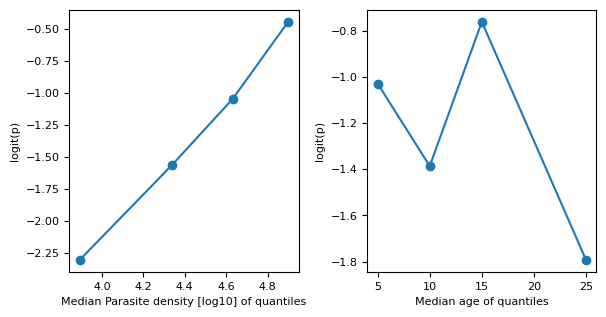

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(W*2, W))
fig.subplots_adjust(wspace=0.3)
ax=axes[0]
ax.plot(df_lincheck_pul['median_pul'],
        df_lincheck_pul['logit_p'], 'o-')
ax.set_ylabel("logit(p)")
ax.set_xlabel("Median Parasite density [log10] of quantiles")

ax=axes[1]
ax.plot(df_lincheck_age['median_age'],
        df_lincheck_age['logit_p'], 'o-')
ax.set_ylabel("logit(p)")
ax.set_xlabel("Median age of quantiles")

if True:
    fig.savefig(f"{DIR_OUTPUT}/plot.linearity_predictors.png", dpi=300)

<Axes: >

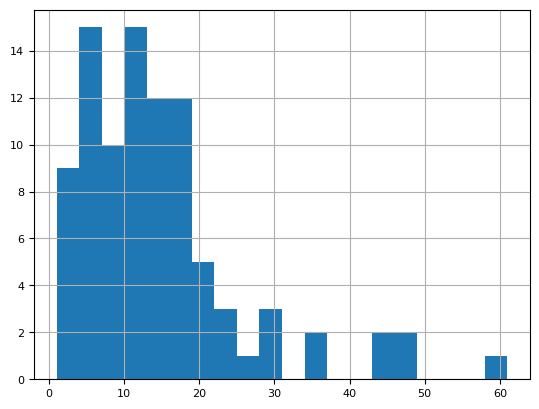

In [64]:
X['age'].hist(bins=20)

- Now need to write this to a file

## Sensitivity analysis of A724E association with day-3 positivity

#### Assume all lost to follow-up were day-3 negative
- From this analysis, those without a DBS collected need to be removed?

Repeat the risk difference analysis, and the odds ratio analysis with Firth's, fisher's exact test

In [65]:
pd.crosstab(df_enrolled["status"],
            df_enrolled["day3_pos"],
            dropna=False,
            margins=True)

day3_pos,False,True,NaN,All
status,,,,
complete,82,21,0,103
lost,0,0,85,85
All,82,21,0,188


- Here is our existing data
- We can see the 85 individuals lost to follow-up
- For these, the day3_pos status in NaN
- First, we assign them to the negative category

In [66]:
df_enrolled['day3_pos_sens'] = df_enrolled['day3_pos'].fillna(False) # assigned as negatives

/var/folders/w7/hc0fpn2s7ll378x1vzz2_pr00000gq/T/ipykernel_88349/2135895541.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_enrolled['day3_pos_sens'] = df_enrolled['day3_pos'].fillna(False) # assigned as negatives


###### Fisher's Exact Test

In [67]:
df_filter_sens = (df_enrolled.query("day0_seqdone") # sequenced 
                  .query("day0_a724_mutant != 'failed'") # passed QC
)

In [68]:
pd.crosstab(df_filter_sens["status"],
            df_filter_sens["day3_pos_sens"],
            dropna=False,
            margins=True) # removing failures

day3_pos_sens,False,True,All
status,,,
complete,77,21,98
lost,77,0,77
All,154,21,175


- Now we have the new crosstable, where all the lost individuals are set as negatives
- We have 154 negatives, and 21 positives
- Now let's prepare the crosstable for the sensitivity analysis

In [69]:
ct_day3_sens = pd.crosstab(
    df_filter_sens["day0_a724_mutant"],
    df_filter_sens["day3_pos_sens"],
    margins='All',
)
ct_day3_nomarg_sens = pd.crosstab(
    df_filter_sens["day0_a724_mutant"],
    df_filter_sens["day3_pos_sens"]
)
ct_day3_sens # clean this table, and write it

day3_pos_sens,False,True,All
day0_a724_mutant,,,
mutant,117,21,138
wildtype,37,0,37
All,154,21,175


In [70]:
print(f""" 
Observed data: {ss.fisher_exact(ct_day3_nomarg)}
Sensitivity analysis: {ss.fisher_exact(ct_day3_nomarg_sens)}
""")

 
Observed data: SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(0.0026872130633147726))
Sensitivity analysis: SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(0.008309080191371138))



- the association weakens, but we are still significant
- let's compute the risk ratios and whatnot

In [71]:
print("Method: Clopper-Pearson")
print(f" Risk of day-3 positivity for A724E (%): {get_exact_cis(n=ct_day3_nomarg_sens.loc['mutant'][True], 
                                                                N=ct_day3_nomarg_sens.loc['mutant'].sum(),
                                                                method='beta')
                                                                }")
print(f" Risk of day-3 positivity for WT (%): {get_exact_cis(n=ct_day3_nomarg_sens.loc['wildtype'][True], 
                                                             N=ct_day3_nomarg_sens.loc['wildtype'].sum(),
                                                             method='beta'
                                                            )}")

Method: Clopper-Pearson
 Risk of day-3 positivity for A724E (%): 15.2 (9.7-22.3)
 Risk of day-3 positivity for WT (%): 0.0 (0.0-9.5)


In [72]:
# Now the risk difference...
ci_low, ci_high = confint_proportions_2indep(
    count1=ct_day3_nomarg_sens.loc['mutant'][True],
    nobs1=ct_day3_nomarg_sens.loc['mutant'].sum(),
    count2=ct_day3_nomarg_sens.loc['wildtype'][True],
    nobs2=ct_day3_nomarg_sens.loc['wildtype'].sum(),
    compare="diff", method="newcomb", alpha=0.05)
print(f"Risk difference 95% CI (%): {100*ci_low:.2f} to {100*ci_high:.2f}")

Risk difference 95% CI (%): 4.54 to 22.15


- This all looks good
- Now we repeat the multivariable analysis with Firth's penalization

In [73]:
df_filter_sens["outcome"] = df_filter_sens["day3_pos_sens"].astype(int)
M = df_filter_sens[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].isna().sum().sum()
df_filter_sens[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].isna().sum() # missingness

age                            2
day0_parasite_density_log10    3
sex                            1
fever                          7
day0_a724_mutant               0
outcome                        0
dtype: int64

In [74]:
print(f"A total of {P(M, df_filter_sens.shape[0])} are missing.")
print(f"A total of {P(df_filter_sens.shape[0] - M, df_filter_sens.shape[0])} are remaining.")

A total of 13 (7.43%) of 175 are missing.
A total of 162 (92.57%) of 175 are remaining.


In [75]:
_df = df_filter_sens[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].dropna()
# note association gets even stronger if we remove fever as a covariate, and recover six patients
# _df = df_filter[["age", "day0_parasite_density_log10", "sex", "day0_a724_mutant", "outcome"]].dropna() 
X = sm.add_constant(
    pd.concat([
        _df[["age", "day0_parasite_density_log10"]],
        #_df[["day0_parasite_density_log10"]], # already added
        pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
        pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),
        pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                     columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
    ],
              axis=1)
)
y = _df["outcome"]

In [76]:
model_sens = FirthLogit(y, X).fit()
print(model_sens.summary())

                      Firth Logistic Regression Results                       
Solver:            Newton-Raphson      No. Observations:         163
Converged:         True                No. Events:                21
No. Iterations:    10                  Df Model:                   5
Log-Likelihood:    -45.861             Df Residual:              157
                  coef   std err         z     P>|z|    [0.025    0.975]
------------------------------------------------------------------------------
       const  -11.1796    3.4219   -3.2671    0.0003  -19.0916   -4.7257
         age    0.0061    0.0258    0.2366    0.8231   -0.0524    0.0570
day0_parasit    1.6338    0.6651    2.4565    0.0116    0.3465    3.1141
       sex_M   -0.7571    0.4896   -1.5463    0.1265   -1.7970    0.2105
   fever_Yes    0.3200    0.5264    0.6080    0.5572   -0.7828    1.3545
  724_mutant    2.3400    1.3752    1.7016    0.0197    0.2856    7.1993
P-values: Penalized likelihood ratio test | CIs: Profil

In [77]:
df_firth = convert_logistic_to_output_table(model_sens)
df_firth

,Odds Ratio (95% CI),P
Covariate,,
Intercept,0.0 (0.0-0.0),0.000
Age,1.0 (0.9-1.1),0.823
Parasity density [log10],5.1 (1.4-22.5),0.012
Sex,0.5 (0.2-1.2),0.126
Fever,1.4 (0.5-3.9),0.557
724E (Mutant),10.4 (1.3-1338.5),0.020


- Done -- can look at hypergeometric argument at bottom of this section

#### Tipping-point analysis of non-adherence
Let's write some functions to simplify code

In [78]:
103/188

0.5478723404255319

In [79]:
def run_day3_multivariable(df: pd.DataFrame, outcome: str = "outcome"):
    """
    Run Firth's multivariable regression for A724E day3 association
    """
    
    # Drop missing; could record
    _df = df[['age', 'day0_parasite_density_log10', 'sex', 'fever', 'day0_a724_mutant', 'outcome']].copy().dropna()
    
    # Prepare data
    X = sm.add_constant(
        pd.concat([
            _df[["age", "day0_parasite_density_log10"]],
            #_df[["day0_parasite_density_log10"]], # already added
            pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
            pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),
            pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                         columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
        ],
                  axis=1)
    )
    y = _df["outcome"]

    # Run model
    model = FirthLogit(y, X).fit()

    return model

In [80]:
@dataclass
class TippingResults:
    """
    Store results from a sensitivity analysis of A724E day-3 positivity
    """
    # Counts
    k: int
    n_day3_a724e: int
    n_total_a724e: int

    # Risk
    risk_a724e: str
    # risk_a724e_lowci: float
    # risk_a724e_highci: float

    # Fisher's exact test
    fishers_p: float

    # Logistic regression
    n_total: int
    n_complete_cases: int
    odds_ratio: str
    logit_p: float
    # odds_ratio: float
    # odds_ratio_lowci: float
    # odds_ratio_highci: float

In [81]:
# Step 1, remove by diference
# df_filter # here are our 98 returned patients
# we order them by smallest decrease in parasitemia
df_filter['parasite_density_log10_diff'] = df_filter['day0_parasite_density_log10'] - df_filter['day3_parasite_density_log10']
# NaN = day-3 negative, these get sorted *AFTER* day-3 positive

In [82]:
# Prepare data for tipping analysis
df_tipping = df_filter.sort_values('parasite_density_log10_diff', ascending=True).copy()
ct_tipping = ct_day3_nomarg.copy()

K = 11
tipping = []
for k in np.arange(1, K):
    # Univariable
    ct_tipping.loc['mutant', True] -= 1 # remove entire row, patient was invalid
    n_day3_a724e = ct_tipping.loc['mutant', True]
    n_total_a724e = ct_tipping.loc['mutant'].sum()
    risk_a724e = get_exact_cis(n=n_day3_a724e, N=n_total_a724e, method='beta')
    fishers_p = ss.fisher_exact(ct_tipping).pvalue

    # Multivariable
    df_tipping = df_tipping.iloc[1:] # remove the patient
    model = run_day3_multivariable(df_tipping)
    _df_logit = convert_logistic_to_output_table(model)
    
    tipping.append(TippingResults(
        k,
        n_day3_a724e, n_total_a724e, risk_a724e, fishers_p,
        n_total=df_tipping.shape[0],
        n_complete_cases=model.nobs,
        odds_ratio=_df_logit.loc['724E (Mutant)'].iloc[0],
        logit_p=_df_logit.loc['724E (Mutant)'].iloc[1])
    )

In [83]:
df_tipping = pd.DataFrame(tipping)
df_tipping["count_day3_a724e"] = [f"{n} (of {N})" for n, N in zip(df_tipping["n_day3_a724e"], df_tipping["n_total_a724e"])]

In [84]:
save_columns = ['k', 'count_day3_a724e', 'risk_a724e', 'fishers_p', 'odds_ratio', 'logit_p']
df_tipping[save_columns] # looks good

,k,count_day3_a724e,risk_a724e,fishers_p,odds_ratio,logit_p
0,1,20 (of 74),27.0 (17.4-38.6),0.002794,12.1 (1.4-1595.2),0.018
1,2,19 (of 73),26.0 (16.5-37.6),0.005180,11.7 (1.3-1569.2),0.023
2,3,18 (of 72),25.0 (15.5-36.6),0.005160,11.2 (1.2-1506.9),0.027
3,4,17 (of 71),23.9 (14.6-35.5),0.009871,11.2 (1.2-1510.7),0.029
4,5,16 (of 70),22.9 (13.7-34.4),0.009525,10.7 (1.2-1457.1),0.034
5,6,15 (of 69),21.7 (12.7-33.3),0.018437,10.2 (1.0-1423.6),0.047
6,7,14 (of 68),20.6 (11.7-32.1),0.017452,9.5 (0.9-1324.9),0.059
7,8,13 (of 67),19.4 (10.8-30.9),0.033624,8.4 (0.9-1160.6),0.072
8,9,12 (of 66),18.2 (9.8-29.6),0.031625,8.1 (0.8-1116.1),0.080
9,10,11 (of 65),16.9 (8.8-28.3),0.059928,7.0 (0.7-962.7),0.102


In [85]:
if save_results:
    df_tipping[save_columns].to_csv(f"{DIR_OUTPUT}/table.tipping_analysis.csv", index=False)
    df_tipping[save_columns].to_excel(f"{DIR_OUTPUT}/table.tipping_analysis.xlsx", index=False)

### Hypergeometric argument about likelihood of the sensitivity analysis

- Imagine, we had 21 of 138 day-3 positive A724E carriers
- What are the odds of getting all of 21 in 75 draws?

In [86]:
ct_day3_sens

day3_pos_sens,False,True,All
day0_a724_mutant,,,
mutant,117,21,138
wildtype,37,0,37
All,154,21,175


In [87]:
ss.hypergeom.pmf(M=138, n=75, N=21, k=21) * 10**6

np.float64(0.6167514541927658)

In [88]:
df_filter_sens.shape[0], df_filter.shape[0], df_filter_sens['day3_pos'].sum()

(175, 98, 21)

In [89]:
# 1.8x10-6
# less than 1 in 500 thousand

### Hypergeometric of the tipping point
- Let's say it *is* caused by non-adherence
- There would need to be 7 or greater non-adherent cases
- And they would all need to be A724E

In [90]:
7 / 98

0.07142857142857142

In [91]:
ss.hypergeom.pmf(M=98, n=75, N=7, k=7) # 14% chance 7 non-adherents are all A724E

np.float64(0.14347047671574412)

In [92]:
if save_results:
    # Univariate
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.csv")
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.xlsx")

    # Logistic, with Firth
    df_firth.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.csv")
    df_firth.to_excel(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.xlsx")

In [93]:
a724_cols = [sns.color_palette("Spectral", 10)[0], (1,1,1)]

/var/folders/w7/hc0fpn2s7ll378x1vzz2_pr00000gq/T/ipykernel_88349/671133298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/w7/hc0fpn2s7ll378x1vzz2_pr00000gq/T/ipykernel_88349/671133298.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1, 1), loc='upper left')


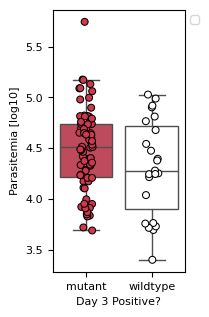

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(W/2, W))

sns.boxplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
    #hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=False,
    # edgecolor='black',
    # linewidth=0.75,
    showfliers=False,
    data=df_filter,
    
)

sns.stripplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
    hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=False,
    edgecolor='black',
    linewidth=0.75,
    data=df_filter
)

ax.set_xlabel("Day 3 Positive?")
ax.set_ylabel("Parasitemia [log10]")

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

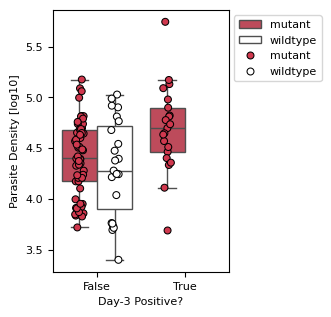

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(W/1.5, W))

sns.boxplot(
    x="day3_pos",
    y="day0_parasite_density_log10",
    hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=True,
    # edgecolor='black',
    # linewidth=0.75,
    showfliers=False,
    data=df_filter,
    
)

sns.stripplot(
    x="day3_pos",
    y="day0_parasite_density_log10",
    hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=True,
    edgecolor='black',
    linewidth=0.75,
    data=df_filter
)

ax.set_xlabel("Day-3 Positive?")
ax.set_ylabel("Parasite Density [log10]")

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

if True:
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [96]:
# By genotype
df_filter.groupby("day0_a724_mutant")["day0_parasite_density_log10"].describe()

,count,mean,std,min,25%,50%,75%,max
day0_a724_mutant,,,,,,,,
mutant,75.0,4.488825,0.402236,3.693815,4.223444,4.513457,4.740363,5.742889
wildtype,23.0,4.316507,0.474484,3.405688,3.904237,4.282033,4.723608,5.028563


In [97]:
df_filter.shape[0], df_filter.query("day0_a724_mutant == 'mutant'").shape[0], df_filter.query("day0_a724_mutant == 'wildtype'").shape[0]

(98, 75, 23)

In [98]:
ss.mannwhitneyu(
    x=df_filter.query("day0_a724_mutant == 'mutant'")["day0_parasite_density_log10"],
    y=df_filter.query("day0_a724_mutant == 'wildtype'")["day0_parasite_density_log10"],
)

MannwhitneyuResult(statistic=np.float64(1033.0), pvalue=np.float64(0.15413874862248989))

In [99]:
10**df_filter.groupby("day0_a724_mutant")["day0_parasite_density_log10"].describe()

,count,mean,std,min,25%,50%,75%,max
day0_a724_mutant,,,,,,,,
mutant,1.000000e+75,30819.435951,2.524851,4941.0,16727.984278,32618.0,55000.00000,553209.0
wildtype,1.000000e+23,20725.613066,2.981837,2545.0,8021.159517,19144.0,52918.60514,106798.0


In [100]:
10**(df_filter['day0_parasite_density_log10'] - df_filter['day3_parasite_density_log10']).describe()

count    1.000000e+21
mean     1.449681e+02
std      4.892352e+00
min      1.082829e+01
25%      3.372671e+01
50%      1.449275e+02
75%      4.062500e+02
max      2.672507e+03
dtype: float64

In [101]:
10**df_filter[['day0_parasite_density_log10', 'day3_parasite_density_log10']].describe()

,day0_parasite_density_log10,day3_parasite_density_log10
count,1.000000e+98,1.000000e+21
mean,2.807908e+04,3.424116e+02
std,2.655355e+00,3.202905e+00
min,2.545000e+03,3.200000e+01
25%,1.623175e+04,1.270000e+02
50%,3.014515e+04,3.820000e+02
75%,5.500000e+04,8.610000e+02
max,5.532090e+05,2.114000e+03


IQR of the densities

## Test intrahost selection with other tests

In [102]:
df_intra = df_filter.query("day3_seqdone and day3_a724_mutant != 'failed'")
df_intra_pos = df_intra.query("day3_pos") # should I only show day 3+?
df_intra.shape[0], df_intra_pos.shape[0]

(20, 17)

In [103]:
ss.wilcoxon(
    df_intra_pos['day0_a724_wsaf'],
    df_intra_pos['day3_a724_wsaf'],
)

WilcoxonResult(statistic=np.float64(20.0), pvalue=np.float64(0.013063960833068166))

In [104]:
df_intra_pos['wsaf_diff'] = (
    df_intra_pos['day3_a724_wsaf'] - df_intra_pos['day0_a724_wsaf']
)
df_intra_pos['increase'] = (df_intra_pos['wsaf_diff'] > 0)

In [105]:
df_intra_hetchange = df_intra_pos.query("day0_a724_gt == '0/1'")[
    ["sample_id", "day0_a724_wsaf", "day3_a724_wsaf", "day0_a724_gt", "day3_a724_gt", "wsaf_diff", "increase"]
    ]

In [106]:
ss.binomtest(
    k=df_intra_hetchange['increase'].sum(),
    n=df_intra_hetchange.shape[0],
    p=0.5
) # still significant

BinomTestResult(k=9, n=9, alternative='two-sided', statistic=1.0, pvalue=0.00390625)

In [107]:
ss.binomtest(
    k=df_intra_pos['increase'].sum(),
    n=df_intra_pos.shape[0],
    p=0.5
) # but this doesn't make sense, the clonal samples can't increase

BinomTestResult(k=13, n=17, alternative='two-sided', statistic=0.7647058823529411, pvalue=0.049041748046875)

## Village enrollment

In [109]:
pd.crosstab(
    df_enrolled['village'],
    df_enrolled['status'],
    dropna=False
).sort_values(['complete'], ascending=False).assign(
    n=lambda df: df.complete + df.lost,
    rate=lambda df: round(100*df.complete/df.n))

status,complete,lost,n,rate
village,,,,
mahilo,35,18,53,66.0
mulamba,18,22,40,45.0
site_and_service,12,10,22,55.0
mungongo,9,4,13,69.0
folkland,6,3,9,67.0
zesco,5,3,8,62.0
mugogo,3,0,3,100.0
kashotoko,3,1,4,75.0
mulamatiya,3,3,6,50.0


### At enrollment, were any baseline characteristics correlated with genotype?

In [110]:
df_enrolled.columns

Index(['collection_date', 'collection_time', 'village', 'age', 'sex', 'fever',
       'day3_dbs_collected', 'treatment_history', 'sample_id',
       'infection_rate', 'qualified', 'day0_parasite_density',
       'day3_parasite_density', 'comment', 'day0_parasite_density_log10',
       'day3_parasite_density_log10', 'status', 'day3_pos', 'day0_a724_gt',
       'day0_a724_wsaf', 'day0_a724_dp', 'day0_k13_all', 'day0_k13_wsaf',
       'day0_a724_mutant', 'day0_k13_mutant', 'day3_a724_gt', 'day3_a724_wsaf',
       'day3_a724_dp', 'day3_k13_all', 'day3_k13_wsaf', 'day3_a724_mutant',
       'day3_k13_mutant', 'day0_seqdone', 'day3_seqdone', 'outcome',
       'day0_a724_gt_int', 'day3_pos_sens'],
      dtype='object')

In [111]:
_df_model = df_filter[['day0_a724_mutant', 'day0_parasite_density_log10', 'sex', 'fever', 'age']].dropna()
_df_model['outcome'] = df_filter['day0_a724_mutant'].map({"mutant": 1, "wildtype": 0})

In [112]:
model = smf.logit(
    "outcome ~ age + day0_parasite_density_log10 + C(sex) + C(fever)",
    data=_df_model
).fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.491669
         Iterations 6
                              Results: Logit
Model:                  Logit                Method:               MLE     
Dependent Variable:     outcome              Pseudo R-squared:     0.061   
Date:                   2026-08-24 19:55     AIC:                  100.4671
No. Observations:       92                   BIC:                  113.0760
Df Model:               4                    Log-Likelihood:       -45.234 
Df Residuals:           87                   LL-Null:              -48.170 
Converged:              1.0000               LLR p-value:          0.20885 
No. Iterations:         6.0000               Scale:                1.0000  
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------------
Intercept        

In [113]:
convert_logistic_to_output_table(model)

,Odds Ratio (95% CI),P
Covariate,,
Intercept,0.0 (0.0-2.0),0.083
Sex,0.7 (0.3-2.0),0.551
Fever,0.5 (0.2-2.0),0.362
Age,1.0 (1.0-1.1),0.867
Parasity density [log10],5.0 (1.2-20.5),0.027


In [114]:
ss.mannwhitneyu(
    x=df_filter.query("day0_a724_mutant == 'mutant'")["day0_parasite_density_log10"],
    y=df_filter.query("day0_a724_mutant == 'wildtype'")["day0_parasite_density_log10"],
)

MannwhitneyuResult(statistic=np.float64(1033.0), pvalue=np.float64(0.15413874862248989))

In [115]:
ss.mannwhitneyu(
    x=_df_model.query("day0_a724_mutant == 'mutant'")["day0_parasite_density_log10"],
    y=_df_model.query("day0_a724_mutant == 'wildtype'")["day0_parasite_density_log10"],
)

MannwhitneyuResult(statistic=np.float64(917.5), pvalue=np.float64(0.06220428835026189))

In [116]:
ss.ttest_ind(
    a=_df_model.query("day0_a724_mutant == 'mutant'")["day0_parasite_density_log10"],
    b=_df_model.query("day0_a724_mutant == 'wildtype'")["day0_parasite_density_log10"],
) 

TtestResult(statistic=np.float64(2.147397505643289), pvalue=np.float64(0.03444944190787421), df=np.float64(90.0))

In [117]:
_df_model.value_counts('day0_a724_mutant')

day0_a724_mutant
mutant      72
wildtype    20
Name: count, dtype: int64

In [118]:
df_filter.value_counts('day0_a724_mutant')

day0_a724_mutant
mutant      75
wildtype    23
Name: count, dtype: int64

In [119]:
# significant by t-test

In [120]:
# Parasite density was significantly higher in A724E carriers before treatment, on day 0
# However, even accounting for this in the multivariable model, there is still an association with day 3 positivity
# In the multivariable logistic model, there is a term b_k x_k that adds to the log odds for parasitemia

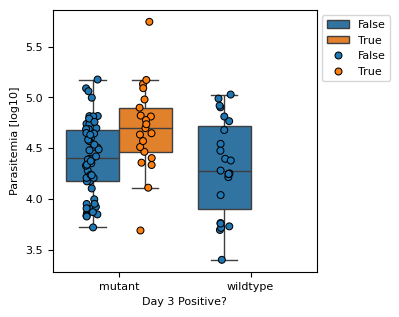

In [121]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

sns.boxplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
    hue="day3_pos",
    #palette=a724_cols,
    dodge=True,
    # edgecolor='black',
    # linewidth=0.75,
    showfliers=False,
    data=df_filter,
    
)

sns.stripplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
    hue="day3_pos",
   # palette=a724_cols,
    dodge=True,
    edgecolor='black',
    linewidth=0.75,
    data=df_filter
)

ax.set_xlabel("Day 3 Positive?")
ax.set_ylabel("Parasitemia [log10]")

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

if False:
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

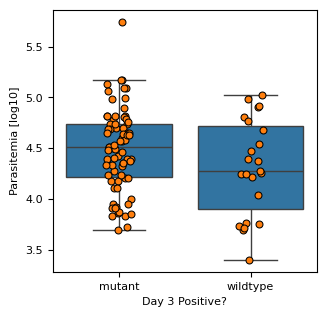

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

sns.boxplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
   # hue="day3_pos",
    #palette=a724_cols,
    dodge=True,
    # edgecolor='black',
    # linewidth=0.75,
    showfliers=False,
    data=df_filter,
    
)

sns.stripplot(
    x="day0_a724_mutant",
    y="day0_parasite_density_log10",
   # hue="day3_pos",
   # palette=a724_cols,
    dodge=True,
    edgecolor='black',
    linewidth=0.75,
    data=df_filter
)

ax.set_xlabel("Day 3 Positive?")
ax.set_ylabel("Parasitemia [log10]")

#ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

if False:
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

6 non-adherent cases to all be A724E

In [ ]:
6 / 98

In [ ]:
7 / 98

In [ ]:
75 / 98